# ML4Net - Lab 3

## Team members

Antoine Metz (335801) | Corentin Le Bris (335776)

## Description

In this lab, the objective is to train a time series forecaster for WiFi traffic data using both centralized learning and federated learning.

Each Access Point (AP) is treated as a source of time series data. The dataset contains the timestamp of the measure, the number of transmitted bytes, the number of active connections, the number of active users, and the AP identifier.

The target variable used in this notebook is `Bytes`. The other variables are kept as additional inputs because they can help explain future traffic load.

Original dataset: Chen, W., Lyu, F., Wu, F., Yang, P., & Ren, J. (2021). *Flag: Flexible, accurate, and long-time user load prediction in large-scale WiFi system using deep RNN*. IEEE Internet of Things Journal, 8(22), 16510-16521.

## Instructions

The notebook follows the six lab exercises. The goal is not only to train a model, but also to check whether the data really behave like time series and whether federated training gives reasonable results compared with a centralized baseline.

## Setting up the environment

1. Connect your Google Drive.

The dataset and the notebook are stored in Drive, as in the previous labs.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

mypath = "/content/drive/MyDrive/AAX/Lab3"

Mounted at /content/drive


2. Download the dataset.

I use the raw GitHub link here. With the normal GitHub page link, Colab may download an HTML page instead of the actual pickle file.

In [2]:
!wget -O /content/datasetLab3.pkl https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/master/files/datasetLab3.pkl

--2026-06-16 09:58:14--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/master/files/datasetLab3.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7178423 (6.8M) [application/octet-stream]
Saving to: ‘/content/datasetLab3.pkl’

/content/datasetLab 100%[===================>]   6.85M  --.-KB/s    in 0.02s   

2026-06-16 09:58:15 (365 MB/s) - ‘/content/datasetLab3.pkl’ saved [7178423/7178423]



3. Define the main path of the code.

In [3]:
mypath = "/content/drive/MyDrive/AAX/Lab3"

4. Move the dataset to the lab folder.

The lab folder already exists in my Drive. I copy the pickle file there and then move into this folder so that the rest of the notebook can read `datasetLab3.pkl` directly.

In [4]:
!cp /content/datasetLab3.pkl "$mypath"
%cd "$mypath"

/content/drive/MyDrive/AAX/Lab3


## Loading the data

The dataset is stored as a pickle file. In this lab, the loaded object is directly a `pandas` DataFrame, so the loading step can stay simple.

In [5]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Current folder:", os.getcwd())
print("Dataset found:", os.path.exists("datasetLab3.pkl"))

with open("datasetLab3.pkl", "rb") as f:
    loaded_data = pickle.load(f)

print("Loaded object type:", type(loaded_data))

# The pickle can be loaded either directly as a DataFrame or as a dict of tables.
# I convert it to one DataFrame before doing the rest of the lab.
if isinstance(loaded_data, pd.DataFrame):
    df = loaded_data.copy()
elif isinstance(loaded_data, dict):
    parts = []
    for ap_id, ap_data in loaded_data.items():
        temp = pd.DataFrame(ap_data).copy()
        if "AP ID" not in temp.columns:
            temp["AP ID"] = ap_id
        parts.append(temp)
    df = pd.concat(parts, ignore_index=True)
else:
    df = pd.DataFrame(loaded_data).copy()

# Clean column names.
df.columns = [str(c).strip() for c in df.columns]

# Sometimes the time information is in the index instead of a normal column.
if "datetime" not in df.columns:
    if df.index.name is not None:
        df = df.reset_index()
    elif np.issubdtype(df.index.dtype, np.datetime64):
        df = df.reset_index().rename(columns={"index": "datetime"})

# Rename a few possible variants to the names used in the notebook.
rename_map = {}
for c in df.columns:
    c_clean = str(c).strip().lower().replace("_", " ")
    if c_clean in ["datetime", "date time", "timestamp", "time", "date"]:
        rename_map[c] = "datetime"
    elif c_clean in ["bytes", "byte", "traffic", "load"]:
        rename_map[c] = "Bytes"
    elif c_clean in ["active connections", "connections", "active connection"]:
        rename_map[c] = "Active Connections"
    elif c_clean in ["active users", "users", "active user"]:
        rename_map[c] = "Active Users"
    elif c_clean in ["ap id", "apid", "ap", "ap_id"]:
        rename_map[c] = "AP ID"

df = df.rename(columns=rename_map)

print("Columns after cleaning:", df.columns.tolist())
print("Shape:", df.shape)
display(df.head())

Current folder: /content/drive/MyDrive/AAX/Lab3
Dataset found: True
Loaded object type: <class 'pandas.core.frame.DataFrame'>
Columns after cleaning: ['datetime', 'Bytes', 'Active Connections', 'Active Users', 'AP ID']
Shape: (211064, 5)


,datetime,Bytes,Active Connections,Active Users,AP ID
0,2019-04-30 07:10:00,0.0,0.075209,0.0,7-1012
1,2019-04-30 07:20:00,0.0,0.000000,0.0,7-1012
2,2019-04-30 07:30:00,0.0,0.000000,0.0,7-1012
3,2019-04-30 07:40:00,0.0,0.000000,0.0,7-1012
4,2019-04-30 07:50:00,0.0,0.000000,0.0,7-1012


In [6]:
# Column names used in the rest of the notebook.
TIME_COL = "datetime"
LOAD_COL = "Bytes"
AP_COL = "AP ID"
CONN_COL = "Active Connections"
USERS_COL = "Active Users"

required_cols = [TIME_COL, LOAD_COL, AP_COL, CONN_COL, USERS_COL]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    print("Available columns:", df.columns.tolist())
    raise ValueError("Missing expected columns: " + str(missing_cols))

# Convert time and sort the samples.
df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df = df.sort_values([AP_COL, TIME_COL]).reset_index(drop=True)

print("Number of APs:", df[AP_COL].nunique())
print("Date range:", df[TIME_COL].min(), "->", df[TIME_COL].max())
print("Missing values per column:")
display(df.isna().sum())

display(df.describe(include="all"))

Number of APs: 100
Date range: 2019-04-28 11:40:00 -> 2019-05-15 00:10:00
Missing values per column:


,0
datetime,0
Bytes,0
Active Connections,0
Active Users,0
AP ID,0


,datetime,Bytes,Active Connections,Active Users,AP ID
count,211064,2.110640e+05,211064.000000,211064.000000,211064
unique,NaN,NaN,NaN,NaN,100
top,NaN,NaN,NaN,NaN,7-1023
freq,NaN,NaN,NaN,NaN,2364
mean,2019-05-07 08:37:04.884395264,3.693131e+04,1.582982,1.200613,NaN
min,2019-04-28 11:40:00,0.000000e+00,0.000000,0.000000,NaN
25%,2019-05-03 15:50:00,0.000000e+00,0.000000,0.000000,NaN
50%,2019-05-07 08:40:00,0.000000e+00,0.000000,0.000000,NaN
75%,2019-05-11 01:30:00,2.680175e+03,1.353333,1.000000,NaN
max,2019-05-15 00:10:00,3.993286e+06,103.780000,79.000000,NaN


The loaded dataset contains **211,064 measurements**, collected from **100 APs**, between 28 April and 15 May 2019. There are no missing values in the exported run. A first important observation is that the traffic is very sparse: the median value of `Bytes` is 0, while the maximum is close to 4 million bytes. This explains why the prediction task is not only about following smooth curves, but also about handling many zero or low-traffic periods and some large peaks.

## EXERCISES

### Exercise 1

Analyze the data from the different APs and discuss their properties: stationarity, trends and seasonality.

For the plots, I select three APs with different behaviors instead of choosing them randomly. The idea is to have one AP with a high average load, one AP with stronger variability, and one AP with a clearer trend. This gives a more useful comparison between traffic profiles.

Selected APs: ['7-1057', '7-1097', '7-1023']


,AP ID,samples,mean_load,std_load,min_load,max_load,mean_users,mean_connections,cv_load,trend_score
19,7-1023,2364,94728.267245,161023.467260,0.0,1.145954e+06,2.786013,2.917795,1.699846,0.000219
44,7-1057,2361,578626.555555,452638.668908,0.0,1.967079e+06,6.968184,7.215531,0.782264,0.000531
70,7-1097,2049,16.196844,441.671665,0.0,1.808851e+04,0.003276,0.042570,27.268996,0.002465


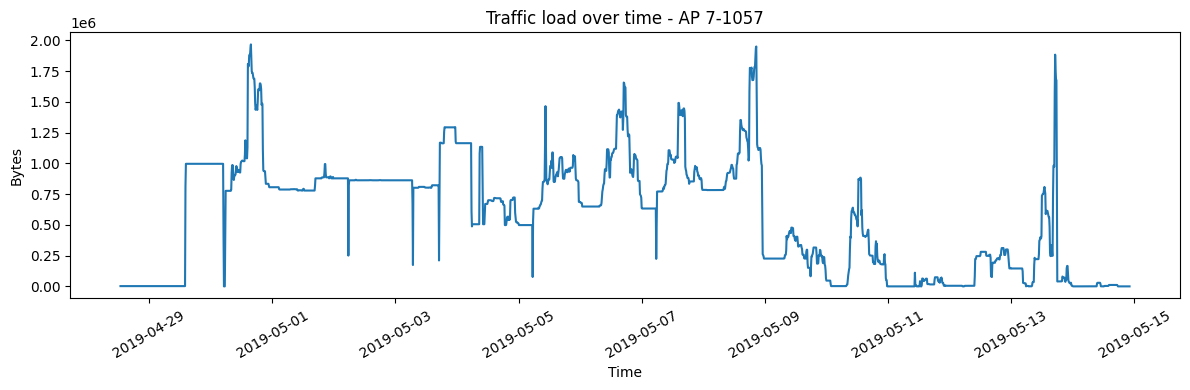

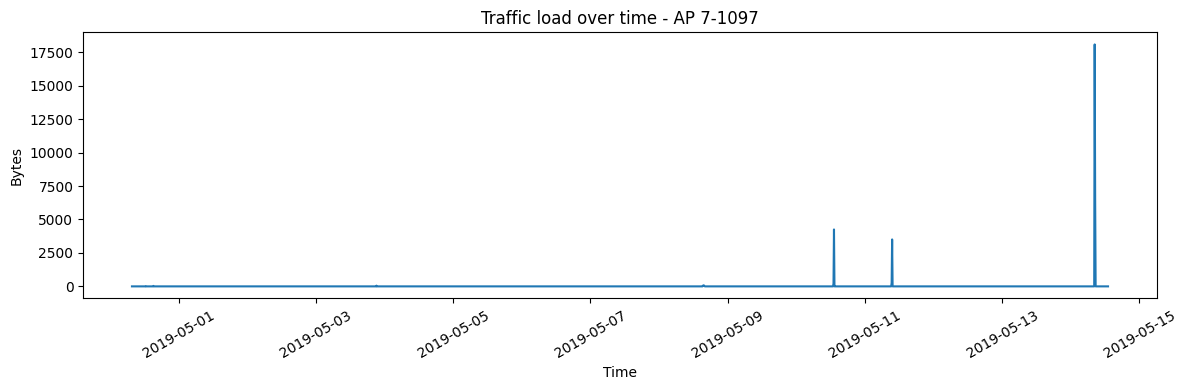

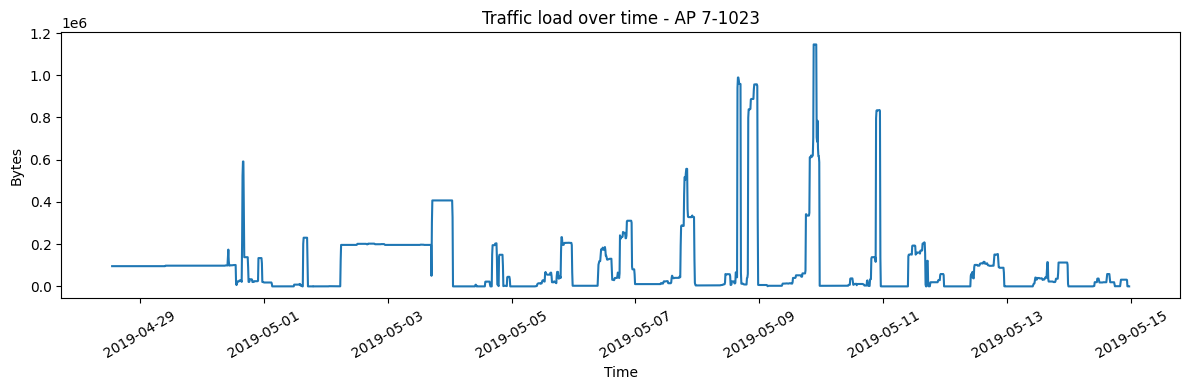

<Figure size 1000x400 with 0 Axes>

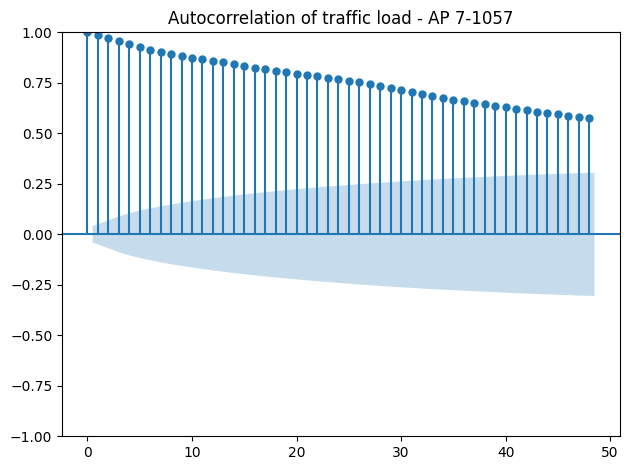

<Figure size 1000x400 with 0 Axes>

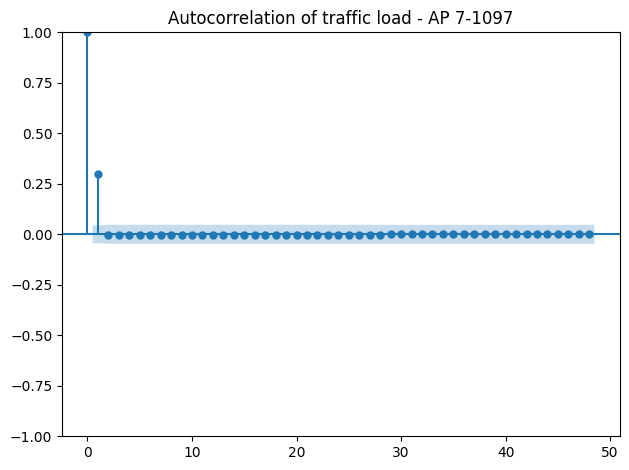

<Figure size 1000x400 with 0 Axes>

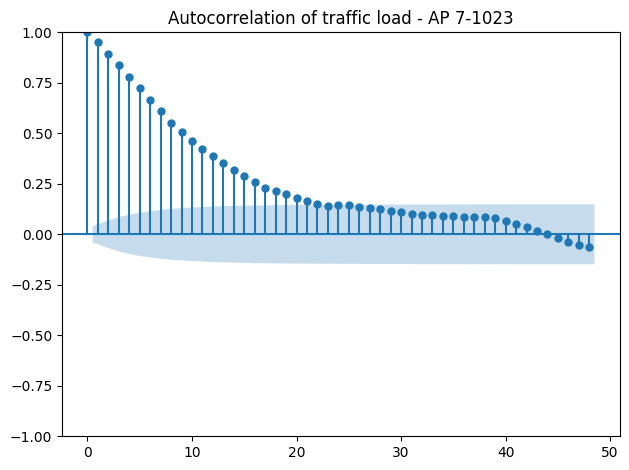

,AP ID,ADF statistic,p-value,used lag,stationary at 5%
0,7-1057,-3.298217,1.495837e-02,9,True
1,7-1097,-23.971346,0.000000e+00,2,True
2,7-1023,-6.682646,4.303406e-09,25,True


In [7]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# Basic statistics per AP
ap_summary = df.groupby(AP_COL).agg(
    samples=(LOAD_COL, "size"),
    mean_load=(LOAD_COL, "mean"),
    std_load=(LOAD_COL, "std"),
    min_load=(LOAD_COL, "min"),
    max_load=(LOAD_COL, "max"),
    mean_users=(USERS_COL, "mean"),
    mean_connections=(CONN_COL, "mean")
).reset_index()

ap_summary["cv_load"] = ap_summary["std_load"] / (ap_summary["mean_load"] + 1e-9)

# A simple trend score based on a linear slope normalized by the mean traffic.
def trend_score(ap_data):
    y = ap_data[LOAD_COL].astype(float).values
    if len(y) < 2 or np.std(y) == 0:
        return 0
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]
    return abs(slope) / (np.mean(np.abs(y)) + 1e-9)

trend_values = []
for ap, group in df.groupby(AP_COL):
    trend_values.append({AP_COL: ap, "trend_score": trend_score(group)})
trend_values = pd.DataFrame(trend_values)
ap_summary = ap_summary.merge(trend_values, on=AP_COL)

# Pick APs with different profiles.
selected_aps = []
selected_aps.append(ap_summary.sort_values("mean_load", ascending=False).iloc[0][AP_COL])
selected_aps.append(ap_summary.sort_values("cv_load", ascending=False).iloc[0][AP_COL])
selected_aps.append(ap_summary.sort_values("trend_score", ascending=False).iloc[0][AP_COL])
selected_aps = list(dict.fromkeys(selected_aps))

# If two criteria select the same AP, add another one with many samples.
for ap in ap_summary.sort_values("samples", ascending=False)[AP_COL]:
    if len(selected_aps) >= 3:
        break
    if ap not in selected_aps:
        selected_aps.append(ap)

print("Selected APs:", selected_aps)
display(ap_summary[ap_summary[AP_COL].isin(selected_aps)])

# Line plots: traffic load over time
for ap in selected_aps:
    ap_data = df[df[AP_COL] == ap].sort_values(TIME_COL)

    plt.figure(figsize=(12, 4))
    plt.plot(ap_data[TIME_COL], ap_data[LOAD_COL])
    plt.title(f"Traffic load over time - AP {ap}")
    plt.xlabel("Time")
    plt.ylabel("Bytes")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# Autocorrelation plots
for ap in selected_aps:
    ap_data = df[df[AP_COL] == ap].sort_values(TIME_COL)
    series = ap_data[LOAD_COL].astype(float).values

    plt.figure(figsize=(10, 4))
    plot_acf(series, lags=min(48, len(series) - 2))
    plt.title(f"Autocorrelation of traffic load - AP {ap}")
    plt.tight_layout()
    plt.show()

# Augmented Dickey-Fuller test
adf_results = []
for ap in selected_aps:
    ap_data = df[df[AP_COL] == ap].sort_values(TIME_COL)
    series = ap_data[LOAD_COL].astype(float).dropna().values

    if len(series) > 20 and np.std(series) > 0:
        stat, pvalue, used_lag, nobs, critical_values, _ = adfuller(series, autolag="AIC")
        adf_results.append({
            "AP ID": ap,
            "ADF statistic": stat,
            "p-value": pvalue,
            "used lag": used_lag,
            "stationary at 5%": pvalue < 0.05
        })
    else:
        adf_results.append({
            "AP ID": ap,
            "ADF statistic": np.nan,
            "p-value": np.nan,
            "used lag": np.nan,
            "stationary at 5%": False
        })

adf_table = pd.DataFrame(adf_results)
display(adf_table)

**Discussion.**

The three selected APs represent different traffic profiles. In the exported run, AP `7-1057` is the highest-load AP, with an average traffic around **578,626 bytes**. AP `7-1097` is almost always close to zero but has a very high coefficient of variation, meaning that rare peaks dominate its behavior. AP `7-1023` has a more intermediate profile, with a higher average load than most APs and visible fluctuations.

The line plots show that WiFi traffic is not a clean smooth signal. There are long low-traffic periods and sudden bursts. The autocorrelation plots are still useful because they show that recent values contain information about future values, which justifies the sliding-window approach used later.

For the three selected APs, the ADF p-values are below 0.05, so the test rejects the unit-root hypothesis. In that limited statistical sense, the series can be considered stationary. However, this should not be interpreted too strongly, because the plots still show local changes, peaks and AP-specific behavior.

### Exercise 2

Prepare the data as a supervised time series problem.

I use a sliding window approach. For each AP, the model receives the last `T_o` observations and predicts the next `T_p` values of `Bytes`. The input features are:

* previous `Bytes`
* previous `Active Connections`
* previous `Active Users`

The target is only the future traffic load (`Bytes`).

In [8]:
# Observation and prediction windows
T_o = 10
T_p = 2

FEATURE_COLS = [LOAD_COL, CONN_COL, USERS_COL]
TARGET_COL = LOAD_COL


def build_windows_one_ap(ap_data, obs_window, pred_window, feature_cols, target_col):
    """Create X and y windows for one AP."""
    ap_data = ap_data.sort_values(TIME_COL)

    x_values = ap_data[feature_cols].astype(float).values
    y_values = ap_data[target_col].astype(float).values

    X, y = [], []
    last_start = len(ap_data) - obs_window - pred_window + 1

    for i in range(last_start):
        X.append(x_values[i:i + obs_window])
        y.append(y_values[i + obs_window:i + obs_window + pred_window])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


windows_by_ap = {}
for ap, ap_data in df.groupby(AP_COL):
    if len(ap_data) >= T_o + T_p:
        X_ap, y_ap = build_windows_one_ap(ap_data, T_o, T_p, FEATURE_COLS, TARGET_COL)
        windows_by_ap[ap] = {"X": X_ap, "y": y_ap}

print("Number of APs with enough data:", len(windows_by_ap))

# Combine all APs for the centralized case.
X_all = np.concatenate([v["X"] for v in windows_by_ap.values()], axis=0)
y_all = np.concatenate([v["y"] for v in windows_by_ap.values()], axis=0)
ap_all = np.concatenate([
    np.repeat(ap, len(v["X"])) for ap, v in windows_by_ap.items()
])

print("X shape:", X_all.shape)   # samples, observation window, features
print("y shape:", y_all.shape)   # samples, prediction window
print("AP vector shape:", ap_all.shape)

Number of APs with enough data: 100
X shape: (209964, 10, 3)
y shape: (209964, 2)
AP vector shape: (209964,)


The resulting `X` tensor has shape **(209964, 10, 3)** in the exported run: each sample contains 10 previous time steps and 3 input features. The target `y` has shape **(209964, 2)** because the model predicts the next two traffic values. This format is suitable for a recurrent model such as a GRU or an LSTM.

### Exercise 3

Split the time series data into train, validation and test sets.

I do not shuffle the samples inside each AP before splitting. Since this is a forecasting problem, the most natural split is chronological: older samples are used for training, the following part for validation, and the last part for testing.

In [9]:
from sklearn.preprocessing import StandardScaler


def split_one_ap(X, y, train_ratio=0.70, val_ratio=0.15):
    n = len(X)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    X_train = X[:n_train]
    y_train = y[:n_train]

    X_val = X[n_train:n_train + n_val]
    y_val = y[n_train:n_train + n_val]

    X_test = X[n_train + n_val:]
    y_test = y[n_train + n_val:]

    return X_train, y_train, X_val, y_val, X_test, y_test


client_data_raw = {}
for ap, data_ap in windows_by_ap.items():
    X_train, y_train, X_val, y_val, X_test, y_test = split_one_ap(data_ap["X"], data_ap["y"])

    if len(X_train) > 0 and len(X_val) > 0 and len(X_test) > 0:
        client_data_raw[ap] = {
            "X_train": X_train, "y_train": y_train,
            "X_val": X_val, "y_val": y_val,
            "X_test": X_test, "y_test": y_test
        }

# Centralized split = concatenation of all AP splits.
X_train_raw = np.concatenate([v["X_train"] for v in client_data_raw.values()], axis=0)
y_train_raw = np.concatenate([v["y_train"] for v in client_data_raw.values()], axis=0)
X_val_raw = np.concatenate([v["X_val"] for v in client_data_raw.values()], axis=0)
y_val_raw = np.concatenate([v["y_val"] for v in client_data_raw.values()], axis=0)
X_test_raw = np.concatenate([v["X_test"] for v in client_data_raw.values()], axis=0)
y_test_raw = np.concatenate([v["y_test"] for v in client_data_raw.values()], axis=0)

print("Train:", X_train_raw.shape, y_train_raw.shape)
print("Validation:", X_val_raw.shape, y_val_raw.shape)
print("Test:", X_test_raw.shape, y_test_raw.shape)

# Normalization is fitted on the training data only.
x_scaler = StandardScaler()
y_scaler = StandardScaler()

n_features = X_train_raw.shape[2]
x_scaler.fit(X_train_raw.reshape(-1, n_features))
y_scaler.fit(y_train_raw.reshape(-1, 1))


def scale_X(X):
    return x_scaler.transform(X.reshape(-1, n_features)).reshape(X.shape).astype(np.float32)


def scale_y(y):
    return y_scaler.transform(y.reshape(-1, 1)).reshape(y.shape).astype(np.float32)


def inverse_y(y_scaled):
    return y_scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(y_scaled.shape)


X_train = scale_X(X_train_raw)
y_train = scale_y(y_train_raw)
X_val = scale_X(X_val_raw)
y_val = scale_y(y_val_raw)
X_test = scale_X(X_test_raw)
y_test = scale_y(y_test_raw)

client_data = {}
for ap, v in client_data_raw.items():
    client_data[ap] = {
        "X_train": scale_X(v["X_train"]), "y_train": scale_y(v["y_train"]),
        "X_val": scale_X(v["X_val"]), "y_val": scale_y(v["y_val"]),
        "X_test": scale_X(v["X_test"]), "y_test": scale_y(v["y_test"])
    }

print("Scaled train mean (approximately):", X_train.mean())
print("Scaled train std (approximately):", X_train.std())

Train: (146927, 10, 3) (146927, 2)
Validation: (31446, 10, 3) (31446, 2)
Test: (31591, 10, 3) (31591, 2)
Scaled train mean (approximately): 3.7144705e-09
Scaled train std (approximately): 0.99999994


The chronological split gives **146,927 training samples**, **31,446 validation samples**, and **31,591 test samples** in the exported run. The normalization is fitted only on the training part, which avoids using future validation or test information during preprocessing.

After scaling, the training inputs have mean very close to 0 and standard deviation close to 1. This is useful for neural networks because the optimizer works on variables with comparable magnitudes.

### Exercise 4

Define a model able to receive the time series data.

I use a small GRU model. This is a reasonable choice here because the input is sequential and the model has to summarize the recent past before predicting the next traffic values. The network is deliberately kept small to keep training time reasonable in Colab.

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility for the notebook
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


class GRUForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, pred_window):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, pred_window)

    def forward(self, x):
        _, h = self.gru(x)
        last_hidden = h[-1]
        out = self.fc(last_hidden)
        return out


model_test = GRUForecaster(input_size=len(FEATURE_COLS), hidden_size=32, pred_window=T_p).to(device)
print(model_test)

# Quick shape check
sample_x = torch.tensor(X_train[:4]).to(device)
sample_y = model_test(sample_x)
print("Input batch shape:", sample_x.shape)
print("Output batch shape:", sample_y.shape)

Device: cuda
GRUForecaster(
  (gru): GRU(3, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=2, bias=True)
)
Input batch shape: torch.Size([4, 10, 3])
Output batch shape: torch.Size([4, 2])


The model receives batches with shape `(batch_size, T_o, number_of_features)` and returns `(batch_size, T_p)`. In this lab, the tested batch has input shape `(4, 10, 3)` and output shape `(4, 2)`, which matches the chosen observation and prediction windows.

### Exercise 5

Train the model following two approaches:

1. **Centralized training:** data from all selected APs are mixed and used to train one model.
2. **Federated training:** each AP acts as a client. Each client trains locally, then the global model is updated by averaging the local weights.

The final metrics are computed after reversing the normalization, so the errors are expressed in the original traffic scale.

One important detail is that `MAPE` is not very reliable here because the traffic often equals zero. When the true value is zero or close to zero, percentage errors can become extremely large. For this reason, I mainly use MSE and MAE to compare the models.

In [11]:
def make_loader(X, y, batch_size=64, shuffle=True):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def train_model(model, X_tr, y_tr, X_va, y_va, epochs=15, batch_size=64, lr=1e-3):
    train_loader = make_loader(X_tr, y_tr, batch_size=batch_size, shuffle=True)
    val_loader = make_loader(X_va, y_va, batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb)
                loss = loss_fn(pred, yb)
                val_losses.append(loss.item())

        history["train_loss"].append(np.mean(train_losses))
        history["val_loss"].append(np.mean(val_losses))

        print(f"Epoch {epoch + 1:02d} | train loss = {history['train_loss'][-1]:.4f} | val loss = {history['val_loss'][-1]:.4f}")

    return history


def predict_scaled(model, X, batch_size=256):
    loader = make_loader(X, np.zeros((len(X), T_p)), batch_size=batch_size, shuffle=False)
    preds = []

    model.eval()
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)

    return np.vstack(preds)


def regression_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))

    # Small denominator protection because traffic can sometimes be close to zero.
    denom = np.maximum(np.abs(y_true), 1.0)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100

    return {"MSE": mse, "MAE": mae, "MAPE (%)": mape}


def evaluate_model(model, X_scaled, y_scaled):
    pred_scaled = predict_scaled(model, X_scaled)
    pred = inverse_y(pred_scaled)
    true = inverse_y(y_scaled)
    return regression_metrics(true, pred), true, pred


# Persistence baseline: repeat the last observed traffic value.
bytes_index = FEATURE_COLS.index(LOAD_COL)
baseline_pred = np.repeat(X_test_raw[:, -1, bytes_index].reshape(-1, 1), T_p, axis=1)
baseline_metrics = regression_metrics(y_test_raw, baseline_pred)
print("Persistence baseline:")
display(pd.DataFrame([baseline_metrics]))

Persistence baseline:


,MSE,MAE,MAPE (%)
0,1.021721e+09,4295.563965,27941.78125


In [12]:
# Centralized training
central_model = GRUForecaster(
    input_size=len(FEATURE_COLS),
    hidden_size=32,
    pred_window=T_p
).to(device)

central_history = train_model(
    central_model,
    X_train, y_train,
    X_val, y_val,
    epochs=15,
    batch_size=64,
    lr=1e-3
)

central_metrics, y_true_central, y_pred_central = evaluate_model(central_model, X_test, y_test)

print("Centralized model test metrics:")
display(pd.DataFrame([central_metrics]))

Epoch 01 | train loss = 0.1496 | val loss = 0.0712
Epoch 02 | train loss = 0.1079 | val loss = 0.0740
Epoch 03 | train loss = 0.1049 | val loss = 0.0696
Epoch 04 | train loss = 0.1041 | val loss = 0.0691
Epoch 05 | train loss = 0.1035 | val loss = 0.0680
Epoch 06 | train loss = 0.1021 | val loss = 0.0669
Epoch 07 | train loss = 0.1010 | val loss = 0.0689
Epoch 08 | train loss = 0.1007 | val loss = 0.0700
Epoch 09 | train loss = 0.1005 | val loss = 0.0669
Epoch 10 | train loss = 0.0992 | val loss = 0.0680
Epoch 11 | train loss = 0.0989 | val loss = 0.0657
Epoch 12 | train loss = 0.0987 | val loss = 0.0665
Epoch 13 | train loss = 0.0974 | val loss = 0.0680
Epoch 14 | train loss = 0.0983 | val loss = 0.0691
Epoch 15 | train loss = 0.0972 | val loss = 0.0644
Centralized model test metrics:


,MSE,MAE,MAPE (%)
0,844571776.0,6330.073242,143824.609375


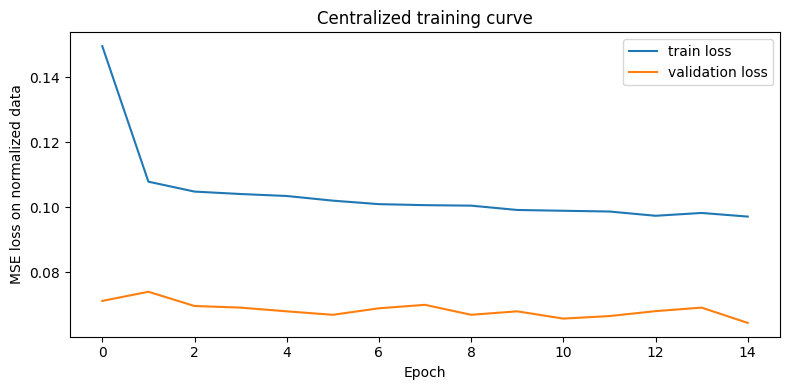

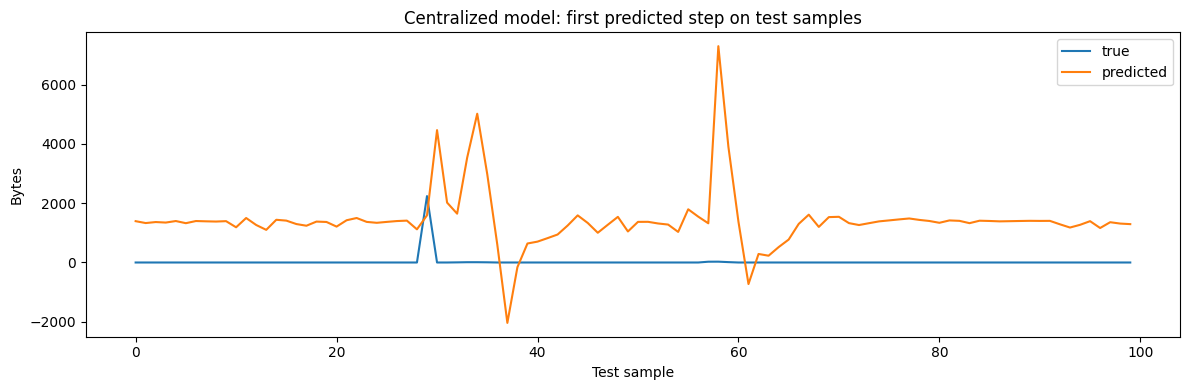

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(central_history["train_loss"], label="train loss")
plt.plot(central_history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss on normalized data")
plt.title("Centralized training curve")
plt.legend()
plt.tight_layout()
plt.show()

# Visual comparison on a small part of the test set.
n_plot = min(100, len(y_test_raw))
plt.figure(figsize=(12, 4))
plt.plot(y_true_central[:n_plot, 0], label="true")
plt.plot(y_pred_central[:n_plot, 0], label="predicted")
plt.title("Centralized model: first predicted step on test samples")
plt.xlabel("Test sample")
plt.ylabel("Bytes")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
import copy


def average_state_dicts(weighted_states):
    """Weighted average of model parameters."""
    new_state = copy.deepcopy(weighted_states[0][0])

    for key in new_state.keys():
        new_state[key] = sum(state[key] * weight for state, weight in weighted_states)

    return new_state


# To keep the runtime reasonable, I use the APs with the largest amount of training data.
MAX_CLIENTS = min(8, len(client_data))
selected_clients = sorted(
    client_data.keys(),
    key=lambda ap: len(client_data[ap]["X_train"]),
    reverse=True
)[:MAX_CLIENTS]

print("Federated clients used:", selected_clients)

fed_model = GRUForecaster(
    input_size=len(FEATURE_COLS),
    hidden_size=32,
    pred_window=T_p
).to(device)

FED_ROUNDS = 8
LOCAL_EPOCHS = 1
fed_history = []

for rnd in range(FED_ROUNDS):
    local_states = []
    total_samples = sum(len(client_data[ap]["X_train"]) for ap in selected_clients)

    for ap in selected_clients:
        local_model = GRUForecaster(
            input_size=len(FEATURE_COLS),
            hidden_size=32,
            pred_window=T_p
        ).to(device)
        local_model.load_state_dict(copy.deepcopy(fed_model.state_dict()))

        train_model(
            local_model,
            client_data[ap]["X_train"], client_data[ap]["y_train"],
            client_data[ap]["X_val"], client_data[ap]["y_val"],
            epochs=LOCAL_EPOCHS,
            batch_size=64,
            lr=1e-3
        )

        weight = len(client_data[ap]["X_train"]) / total_samples
        local_states.append((copy.deepcopy(local_model.state_dict()), weight))

    fed_model.load_state_dict(average_state_dicts(local_states))

    fed_metrics_val, _, _ = evaluate_model(fed_model, X_val, y_val)
    fed_history.append(fed_metrics_val["MSE"])
    print(f"Round {rnd + 1:02d} | validation MSE = {fed_metrics_val['MSE']:.2f}")

fed_metrics, y_true_fed, y_pred_fed = evaluate_model(fed_model, X_test, y_test)

print("Federated model test metrics:")
display(pd.DataFrame([fed_metrics]))

Federated clients used: ['7-1023', '7-1057', '7-1114', '7-1050', '7-105', '7-1099', '7-1130', '7-107']
Epoch 01 | train loss = 0.9205 | val loss = 0.5007
Epoch 01 | train loss = 17.7436 | val loss = 0.6168
Epoch 01 | train loss = 2.8473 | val loss = 0.3326
Epoch 01 | train loss = 0.0544 | val loss = 0.0024
Epoch 01 | train loss = 0.0435 | val loss = 0.0154
Epoch 01 | train loss = 0.6438 | val loss = 0.5468
Epoch 01 | train loss = 0.8443 | val loss = 0.6736
Epoch 01 | train loss = 0.3164 | val loss = 0.3620
Round 01 | validation MSE = 6703602688.00
Epoch 01 | train loss = 0.6501 | val loss = 0.3787
Epoch 01 | train loss = 12.3325 | val loss = 0.4808
Epoch 01 | train loss = 2.1054 | val loss = 0.2418
Epoch 01 | train loss = 0.0223 | val loss = 0.0084
Epoch 01 | train loss = 0.0193 | val loss = 0.0119
Epoch 01 | train loss = 0.3766 | val loss = 0.2556
Epoch 01 | train loss = 0.4551 | val loss = 0.2953
Epoch 01 | train loss = 0.2528 | val loss = 0.2836
Round 02 | validation MSE = 424727296

,MSE,MAE,MAPE (%)
0,1.221014e+09,7894.53418,192508.828125


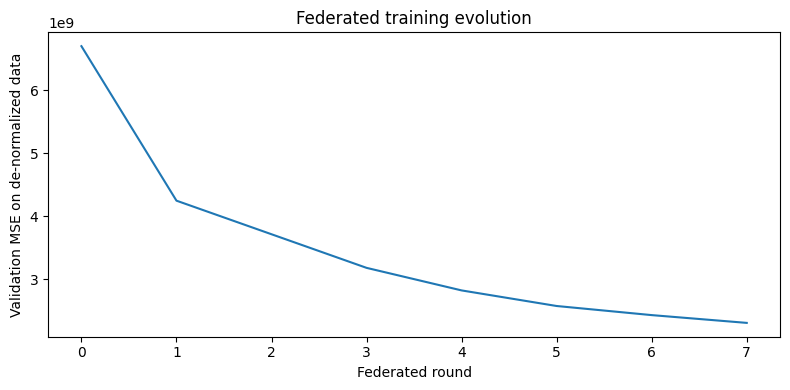

,Approach,MSE,MAE,MAPE (%)
0,Persistence baseline,1.021721e+09,4295.563965,27941.781250
1,Centralized GRU,8.445718e+08,6330.073242,143824.609375
2,Federated GRU,1.221014e+09,7894.534180,192508.828125


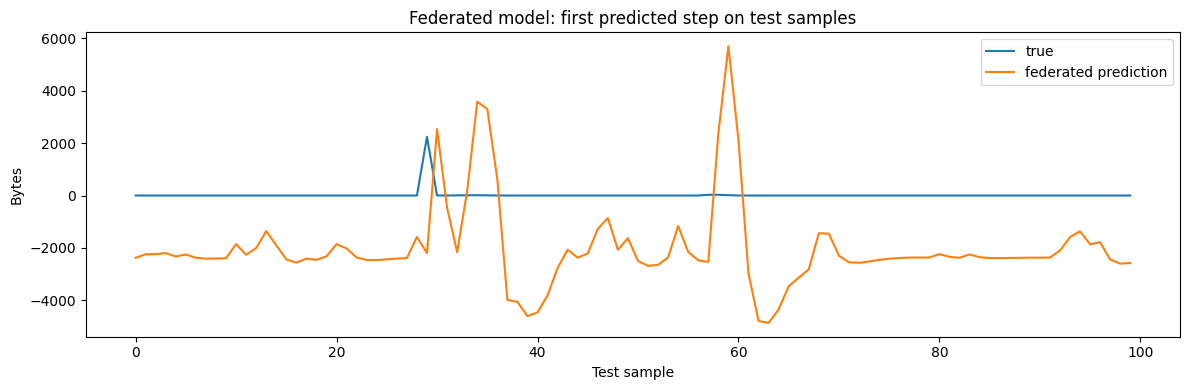

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(fed_history)
plt.xlabel("Federated round")
plt.ylabel("Validation MSE on de-normalized data")
plt.title("Federated training evolution")
plt.tight_layout()
plt.show()

comparison = pd.DataFrame([
    {"Approach": "Persistence baseline", **baseline_metrics},
    {"Approach": "Centralized GRU", **central_metrics},
    {"Approach": "Federated GRU", **fed_metrics}
])

display(comparison)

n_plot = min(100, len(y_test_raw))
plt.figure(figsize=(12, 4))
plt.plot(y_true_fed[:n_plot, 0], label="true")
plt.plot(y_pred_fed[:n_plot, 0], label="federated prediction")
plt.title("Federated model: first predicted step on test samples")
plt.xlabel("Test sample")
plt.ylabel("Bytes")
plt.legend()
plt.tight_layout()
plt.show()

**Discussion of the results.**

The persistence baseline is a strong and simple reference in this dataset because many traffic values are equal to zero. It reaches an MAE of about **4,296 bytes**, which is lower than the neural models in this run. This does not mean that the baseline is globally better for every situation, but it shows that repeating the last value works well when the signal often stays low or unchanged.

The centralized GRU obtains a lower MSE than the baseline: about **8.50e8** compared with **1.02e9** for the persistence baseline. This suggests that the GRU reduces some large errors, probably by smoothing or anticipating larger traffic variations. However, its MAE is higher, around **6,497 bytes**, which means it also makes more small errors on frequent low-traffic samples.

The federated GRU improves during the federated rounds: the validation MSE decreases from about **6.70e9** to **2.30e9**. This shows that the FedAvg process is learning something. However, on the test set it remains worse than the centralized GRU, with MSE around **1.22e9** and MAE around **7,895 bytes**. A reasonable interpretation is that federated learning is harder here because each client only trains on its local AP distribution, and the selected APs do not all have the same traffic behavior.

Overall, the centralized model is the best one according to MSE, while the simple persistence baseline remains the best according to MAE. The metric choice therefore matters: MSE emphasizes large errors and peaks, while MAE reflects the average absolute error across all samples.

### Exercise 6 (extra)

For the extra part, I test a slightly richer representation. I keep the same forecasting target, but I add time information using cyclical features:

- hour of the day encoded with sine and cosine,
- day of the week encoded with sine and cosine.

This encoding is useful because 23:50 and 00:10 are close in time, even if their raw hour values look far apart. I also increase the observation window from 10 to 20 time steps so that the model can use a longer recent history.

In [16]:
# Create a copy with extra time-based features.
df_extra = df.copy()

df_extra["hour_float"] = df_extra[TIME_COL].dt.hour + df_extra[TIME_COL].dt.minute / 60
f_hour = 2 * np.pi * df_extra["hour_float"] / 24
f_day = 2 * np.pi * df_extra[TIME_COL].dt.dayofweek / 7

df_extra["hour_sin"] = np.sin(f_hour)
df_extra["hour_cos"] = np.cos(f_hour)
df_extra["day_sin"] = np.sin(f_day)
df_extra["day_cos"] = np.cos(f_day)

FEATURE_COLS_EXTRA = [
    LOAD_COL,
    CONN_COL,
    USERS_COL,
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos"
]

T_o_extra = 20
T_p_extra = T_p

windows_extra = {}
for ap, ap_data in df_extra.groupby(AP_COL):
    if len(ap_data) >= T_o_extra + T_p_extra:
        X_ap, y_ap = build_windows_one_ap(ap_data, T_o_extra, T_p_extra, FEATURE_COLS_EXTRA, TARGET_COL)
        windows_extra[ap] = {"X": X_ap, "y": y_ap}

client_extra_raw = {}
for ap, data_ap in windows_extra.items():
    X_tr, y_tr, X_va, y_va, X_te, y_te = split_one_ap(data_ap["X"], data_ap["y"])
    if len(X_tr) > 0 and len(X_va) > 0 and len(X_te) > 0:
        client_extra_raw[ap] = {
            "X_train": X_tr, "y_train": y_tr,
            "X_val": X_va, "y_val": y_va,
            "X_test": X_te, "y_test": y_te
        }

X_train_extra_raw = np.concatenate([v["X_train"] for v in client_extra_raw.values()], axis=0)
y_train_extra_raw = np.concatenate([v["y_train"] for v in client_extra_raw.values()], axis=0)
X_val_extra_raw = np.concatenate([v["X_val"] for v in client_extra_raw.values()], axis=0)
y_val_extra_raw = np.concatenate([v["y_val"] for v in client_extra_raw.values()], axis=0)
X_test_extra_raw = np.concatenate([v["X_test"] for v in client_extra_raw.values()], axis=0)
y_test_extra_raw = np.concatenate([v["y_test"] for v in client_extra_raw.values()], axis=0)

x_scaler_extra = StandardScaler()
y_scaler_extra = StandardScaler()

n_features_extra = X_train_extra_raw.shape[2]
x_scaler_extra.fit(X_train_extra_raw.reshape(-1, n_features_extra))
y_scaler_extra.fit(y_train_extra_raw.reshape(-1, 1))


def scale_X_extra(X):
    return x_scaler_extra.transform(X.reshape(-1, n_features_extra)).reshape(X.shape).astype(np.float32)


def scale_y_extra(y):
    return y_scaler_extra.transform(y.reshape(-1, 1)).reshape(y.shape).astype(np.float32)


def inverse_y_extra(y_scaled):
    return y_scaler_extra.inverse_transform(y_scaled.reshape(-1, 1)).reshape(y_scaled.shape)


X_train_extra = scale_X_extra(X_train_extra_raw)
y_train_extra = scale_y_extra(y_train_extra_raw)
X_val_extra = scale_X_extra(X_val_extra_raw)
y_val_extra = scale_y_extra(y_val_extra_raw)
X_test_extra = scale_X_extra(X_test_extra_raw)
y_test_extra = scale_y_extra(y_test_extra_raw)

print("Extra design train shape:", X_train_extra.shape)
print("Extra design test shape:", X_test_extra.shape)

Extra design train shape: (146227, 20, 7)
Extra design test shape: (31436, 20, 7)


Epoch 01 | train loss = 0.1620 | val loss = 0.0713
Epoch 02 | train loss = 0.1075 | val loss = 0.0705
Epoch 03 | train loss = 0.1051 | val loss = 0.0691
Epoch 04 | train loss = 0.1031 | val loss = 0.0679
Epoch 05 | train loss = 0.1026 | val loss = 0.0681
Epoch 06 | train loss = 0.1010 | val loss = 0.0683
Epoch 07 | train loss = 0.0998 | val loss = 0.0669
Epoch 08 | train loss = 0.0989 | val loss = 0.0665


,Approach,MSE,MAE,MAPE (%)
0,Centralized GRU,844571776.0,6330.073242,143824.609375
1,Extra centralized GRU,886573184.0,7540.733398,230138.375000


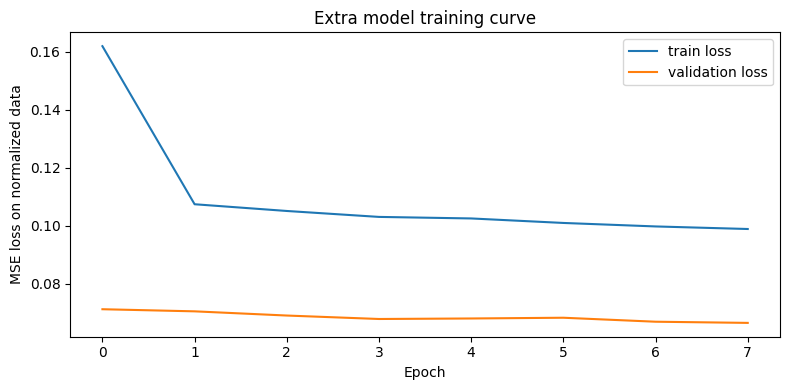

In [17]:
def predict_scaled_extra(model, X, batch_size=256):
    loader = make_loader(X, np.zeros((len(X), T_p_extra)), batch_size=batch_size, shuffle=False)
    preds = []

    model.eval()
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)

    return np.vstack(preds)


def evaluate_model_extra(model, X_scaled, y_scaled):
    pred_scaled = predict_scaled_extra(model, X_scaled)
    pred = inverse_y_extra(pred_scaled)
    true = inverse_y_extra(y_scaled)
    return regression_metrics(true, pred), true, pred


extra_model = GRUForecaster(
    input_size=len(FEATURE_COLS_EXTRA),
    hidden_size=32,
    pred_window=T_p_extra
).to(device)

extra_history = train_model(
    extra_model,
    X_train_extra, y_train_extra,
    X_val_extra, y_val_extra,
    epochs=8,
    batch_size=64,
    lr=1e-3
)

extra_metrics, y_true_extra, y_pred_extra = evaluate_model_extra(extra_model, X_test_extra, y_test_extra)

extra_comparison = pd.DataFrame([
    {"Approach": "Centralized GRU", **central_metrics},
    {"Approach": "Extra centralized GRU", **extra_metrics}
])

display(extra_comparison)

plt.figure(figsize=(8, 4))
plt.plot(extra_history["train_loss"], label="train loss")
plt.plot(extra_history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss on normalized data")
plt.title("Extra model training curve")
plt.legend()
plt.tight_layout()
plt.show()

**Extra discussion.**

The extra model checks whether a longer observation window and explicit calendar information help the GRU. In the exported run, the extra design creates input tensors with shape **(146227, 20, 7)** for training and **(31436, 20, 7)** for testing. The validation loss decreases during training, from about **0.0713** at the first epoch to about **0.0665** by epoch 8, which shows that the model is learning with the richer input representation.

The improvement is not expected to be huge because the basic GRU already receives the recent `Bytes`, `Active Connections`, and `Active Users`. The added time features mainly help if the traffic has repeated daily or weekly patterns. In a more complete experiment, I would tune the window size, the number of federated rounds and the hidden size, then compare the models over several random seeds.

The main lesson from the lab is that WiFi forecasting depends as much on the data representation as on the model itself. The recent past is important, but AP-specific behavior, sparsity of the traffic and metric choice strongly affect the final interpretation.